## Import everything

In [1]:
import sys, os
# sys.path.append("/usr/local/lib/python3.10/site-packages") # path to local installation in google drive

import quspin
print('\nquspin {} installed successfully and ready for use!\n'.format(quspin.__version__) )


os.environ['OMP_NUM_THREADS']='1'             # OpenMP threads to run in parallel
os.environ['MKL_NUM_THREADS']='1'             # MKL threads to run in parallel


from matplotlib import pyplot as plt
plt.rcParams.update({
    "text.usetex": True,                                # enable latex font
    "font.family": "Helvetica",                         # set font style
    "text.latex.preamble": r'\usepackage{amsmath}',     # add latex packages
    "font.size": "16",                                  # set font size
})
%matplotlib inline

import numpy as np
np.set_printoptions(suppress=True,precision=5)

# import time as T
# from numba import jit

from joblib import Parallel, delayed
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
import itertools

# _eps = np.finfo(float).eps
_thresh =  10e-10
def _th(x): return x if abs(x) >= _thresh else 0.0

import matplotlib as mpl

# Set DPI for inline display
mpl.rcParams['figure.dpi'] = 100

from cycler import cycler       


quspin 0.3.7 installed successfully and ready for use!



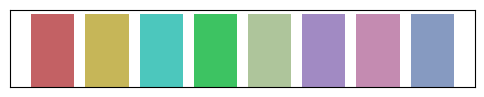

In [2]:
from matplotlib.colors import hsv_to_rgb

def distinct_subdued_colors(
    n,
    sat_range=(0.2, 0.7),
    val_range=(0.75, 0.8),
    hue_jitter=0.0,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)

    base_hues = np.linspace(0, 1, n, endpoint=False)

    if hue_jitter > 0:
        base_hues = (base_hues + np.random.uniform(-hue_jitter, hue_jitter, n)) % 1.0

    sats = np.random.uniform(sat_range[0], sat_range[1], n)
    vals = np.random.uniform(val_range[0], val_range[1], n)
    
    hsv = np.stack([base_hues, sats, vals], axis=1)
    np.random.shuffle(hsv)

    rgb = hsv_to_rgb(hsv)
    return rgb

if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    colors = distinct_subdued_colors(8, seed=42, hue_jitter=0.02)
    fig, ax = plt.subplots(figsize=(6, 1))
    for i, c in enumerate(colors):
        ax.bar(i, 1, color=c)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

## Ground state, reduced density matrix, its derivative and metric response of REE

In [3]:
def compute_ground_state(L, h):
    basis = spin_basis_1d(L, pauli=True, kblock=0)
    three_spin_list = [[-1.0, i, (i+1) % L, (i+2) % L] for i in range(L)]
    transverse_field_list = [[-h, i] for i in range(L)]
    static = [["xxx", three_spin_list], ["z", transverse_field_list]]
    dynamic = []
    H = hamiltonian(static, dynamic, basis=basis, dtype=np.float64, check_symm=False, check_herm=False)
    _, psi0 = H.eigsh(k=1, which='SA')
    return basis, psi0

def RDM(size, h, RDM_size):
    if RDM_size <= size:
        basis_ising, ground_state = compute_ground_state(size, h)
        return basis_ising.ent_entropy(state=ground_state, sub_sys_A=[i for i in range(RDM_size)], return_rdm="A")["rdm_A"]
    else:
        print('RDM_size > system_size : size of reduced density matrix must be smaller than system size')

def d_h_RDM(size, h, RDM_size, tolerance=1e-9):
    _rdm = RDM(size, h, RDM_size)
    return _rdm, (1/tolerance)*(RDM(size, h+tolerance, RDM_size) - _rdm)

def Sigma_h(size, h, RDM_size):
    _rdm, _d_h_rdm = d_h_RDM(size, h, RDM_size)
    return (1/2)*np.trace(np.linalg.inv(_rdm) @ _d_h_rdm @ _d_h_rdm).real

Sigma_h(15, 1, 1)

np.float64(2.7521872193425825)

## Definition of all the correlation-derivatives upto 3 sites

In [4]:
b__1 = spin_basis_1d(1, pauli=True)

z = hamiltonian([["z", [[1.0, 0]]]], [], basis=b__1, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()

b__2 = spin_basis_1d(2, pauli=True)

zz = hamiltonian([["zz", [[1.0, 0, 1]]]], [], basis=b__2, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()


b__3 = spin_basis_1d(3, pauli=True)

zzz = hamiltonian([["zzz", [[1.0, 0, 1, 2]]]], [], basis=b__3, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()

z0z = hamiltonian([["zz", [[1.0, 0,  2]]]], [], basis=b__3, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()

xxx = hamiltonian([["xxx", [[1.0, 0, 1, 2]]]], [], basis=b__3, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()

yxx = hamiltonian([["yyx", [[1.0, 0, 1, 2]]]], [], basis=b__3, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()

yxy = hamiltonian([["yxy", [[1.0, 0, 1, 2]]]], [], basis=b__3, dtype=np.complex128,
                    check_symm=False, check_herm=False, check_pcon=False).toarray()



def one_site_correlation_derivatives_at_once__(h_val, N, tolerance = 10e-9):

    rdm = RDM(size=N, h=h_val, RDM_size=1)
    rdm_forward = RDM(size=N, h=h_val+tolerance, RDM_size=1)
    ez = _th(np.trace(rdm @ z).real)
    ez_forward = _th(np.trace(rdm_forward @ z).real)

    dh_ez = (1/tolerance) * (ez_forward - ez)

    return {"dh_<Z>": dh_ez}



def two_site_correlation_derivatives_at_once__(h_val, N, tolerance = 10e-9):

    rdm = RDM(size=N, h=h_val, RDM_size=2)
    rdm_forward = RDM(size=N, h=h_val+tolerance, RDM_size=2)
    ezz = _th(np.trace(rdm @ zz).real)
    ezz_forward = _th(np.trace(rdm_forward @ zz).real)

    dh_ezz = (1/tolerance) * (ezz_forward - ezz)

    return {"dh_<ZZ>": dh_ezz}


def three_site_correlation_derivatives_at_once__(h_val, N, tolerance = 10e-9):

    rdm = RDM(size=N, h=h_val, RDM_size=3)
    rdm_forward = RDM(size=N, h=h_val+tolerance, RDM_size=3)
    
    exxx = _th(np.trace(rdm @ xxx).real)
    ezzz = _th(np.trace(rdm @ zzz).real)
    eyyx = _th(np.trace(rdm @ yxx).real)
    eyxy = _th(np.trace(rdm @ yxy).real)
    ez0z = _th(np.trace(rdm @ z0z).real)

    exxx_forward = _th(np.trace(rdm_forward @ xxx).real)
    ezzz_forward = _th(np.trace(rdm_forward @ zzz).real)
    eyyx_forward = _th(np.trace(rdm_forward @ yxx).real)
    eyxy_forward = _th(np.trace(rdm_forward @ yxy).real)
    ez0z_forward = _th(np.trace(rdm_forward @ z0z).real)

    dh_exxx = (1/tolerance) * (exxx_forward - exxx)
    dh_ezzz = (1/tolerance) * (ezzz_forward - ezzz)
    dh_eyyx = (1/tolerance) * (eyyx_forward - eyyx)
    dh_eyxy = (1/tolerance) * (eyxy_forward - eyxy)
    dh_ez0z = (1/tolerance) * (ez0z_forward - ez0z)

    return {"dh_<XXX>": dh_exxx, "dh_<ZZZ>": dh_ezzz, "dh_<YXY>": dh_eyxy, "dh_<YYX>": dh_eyyx, 
            "dh_<XYY>": dh_eyyx, "dh_<XYY>": dh_eyyx, "dh_<Z0Z>": dh_ez0z}

hVal = 1.0
N = 12

print(one_site_correlation_derivatives_at_once__(hVal, N)['dh_<Z>'])
print(two_site_correlation_derivatives_at_once__(hVal, N))
print(three_site_correlation_derivatives_at_once__(hVal, N))

1.5616697379705613
{'dh_<ZZ>': np.float64(2.052231584670494)}
{'dh_<XXX>': np.float64(-1.5616708370913557), 'dh_<ZZZ>': np.float64(2.195755299805313), 'dh_<YXY>': np.float64(-0.5597545593705178), 'dh_<YYX>': np.float64(-0.5201375219421323), 'dh_<XYY>': np.float64(-0.5201375219421323), 'dh_<Z0Z>': np.float64(1.9928751981979076)}


In [9]:
from tqdm.notebook import tqdm

CPU_cores = 4
resolution = 256
h_values = np.linspace(0.8, 1.2, resolution)

## Derivatives of non-vanishing correlation functions

In [10]:
one_site__6 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(one_site_correlation_derivatives_at_once__)(h, 6) for h in tqdm(h_values, desc=f"N = {6} || all correlation-derivatives within 1 sites")))
two_site__6 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(two_site_correlation_derivatives_at_once__)(h, 6) for h in tqdm(h_values, desc=f"N = {6} || all correlation-derivatives within 2 sites")))
three_site__6 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(three_site_correlation_derivatives_at_once__)(h, 6) for h in tqdm(h_values, desc=f"N = {6} || all correlation-derivatives within 3 sites")))



dh__Z__6 = np.array([res["dh_<Z>"] for res in one_site__6])

dh__ZZ__6 = np.array([res["dh_<ZZ>"] for res in two_site__6])

dh__XXX__6 = np.array([res["dh_<XXX>"] for res in three_site__6])
dh__ZZZ__6 = np.array([res["dh_<ZZZ>"] for res in three_site__6])
dh__Z0Z__6 = np.array([res["dh_<Z0Z>"] for res in three_site__6])
dh__YYX__6 = np.array([res["dh_<YYX>"] for res in three_site__6])
dh__YXY__6 = np.array([res["dh_<YXY>"] for res in three_site__6])    


N = 6 || all correlation-derivatives within 1 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 6 || all correlation-derivatives within 2 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 6 || all correlation-derivatives within 3 sites:   0%|          | 0/256 [00:00<?, ?it/s]

In [ ]:
one_site__9 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(one_site_correlation_derivatives_at_once__)(h, 9) for h in tqdm(h_values, desc=f"N = {9} || all correlation-derivatives within 1 sites")))
two_site__9 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(two_site_correlation_derivatives_at_once__)(h, 9) for h in tqdm(h_values, desc=f"N = {9} || all correlation-derivatives within 2 sites")))
three_site__9 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(three_site_correlation_derivatives_at_once__)(h, 9) for h in tqdm(h_values, desc=f"N = {9} || all correlation-derivatives within 3 sites")))



dh__Z__9 = np.array([res["dh_<Z>"] for res in one_site__9])

dh__ZZ__9 = np.array([res["dh_<ZZ>"] for res in two_site__9])

dh__XXX__9 = np.array([res["dh_<XXX>"] for res in three_site__9])
dh__ZZZ__9 = np.array([res["dh_<ZZZ>"] for res in three_site__9])
dh__Z0Z__9 = np.array([res["dh_<Z0Z>"] for res in three_site__9])
dh__YYX__9 = np.array([res["dh_<YYX>"] for res in three_site__9])
dh__YXY__9 = np.array([res["dh_<YXY>"] for res in three_site__9])

N = 9 || all correlation-derivatives within 1 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 9 || all correlation-derivatives within 2 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 9 || all correlation-derivatives within 3 sites:   0%|          | 0/256 [00:00<?, ?it/s]

In [12]:
one_site__12 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(one_site_correlation_derivatives_at_once__)(h, 12) for h in tqdm(h_values, desc=f"N = {12} || all correlation-derivatives within 1 sites")))
two_site__12 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(two_site_correlation_derivatives_at_once__)(h, 12) for h in tqdm(h_values, desc=f"N = {12} || all correlation-derivatives within 2 sites")))
three_site__12 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(three_site_correlation_derivatives_at_once__)(h, 12) for h in tqdm(h_values, desc=f"N = {12} || all correlation-derivatives within 3 sites")))


dh__Z__12 = np.array([res["dh_<Z>"] for res in one_site__12])

dh__ZZ__12 = np.array([res["dh_<ZZ>"] for res in two_site__12])

dh__XXX__12 = np.array([res["dh_<XXX>"] for res in three_site__12])
dh__ZZZ__12 = np.array([res["dh_<ZZZ>"] for res in three_site__12])
dh__Z0Z__12 = np.array([res["dh_<Z0Z>"] for res in three_site__12])
dh__YYX__12 = np.array([res["dh_<YYX>"] for res in three_site__12])
dh__YXY__12 = np.array([res["dh_<YXY>"] for res in three_site__12])    

N = 12 || all correlation-derivatives within 1 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 12 || all correlation-derivatives within 2 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 12 || all correlation-derivatives within 3 sites:   0%|          | 0/256 [00:00<?, ?it/s]

In [13]:
one_site__15 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(one_site_correlation_derivatives_at_once__)(h, 15) for h in tqdm(h_values, desc=f"N = {15} || all correlation-derivatives within 1 sites")))
two_site__15 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(two_site_correlation_derivatives_at_once__)(h, 15) for h in tqdm(h_values, desc=f"N = {15} || all correlation-derivatives within 2 sites")))
three_site__15 = np.array(Parallel(n_jobs=CPU_cores)(
              delayed(three_site_correlation_derivatives_at_once__)(h, 15) for h in tqdm(h_values, desc=f"N = {15} || all correlation-derivatives within 3 sites")))

dh__Z__15 = np.array([res["dh_<Z>"] for res in one_site__15])

dh__ZZ__15 = np.array([res["dh_<ZZ>"] for res in two_site__15])

dh__XXX__15 = np.array([res["dh_<XXX>"] for res in three_site__15])
dh__ZZZ__15 = np.array([res["dh_<ZZZ>"] for res in three_site__15])
dh__Z0Z__15 = np.array([res["dh_<Z0Z>"] for res in three_site__15])
dh__YYX__15 = np.array([res["dh_<YYX>"] for res in three_site__15])
dh__YXY__15 = np.array([res["dh_<YXY>"] for res in three_site__15])    

N = 15 || all correlation-derivatives within 1 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 15 || all correlation-derivatives within 2 sites:   0%|          | 0/256 [00:00<?, ?it/s]

N = 15 || all correlation-derivatives within 3 sites:   0%|          | 0/256 [00:00<?, ?it/s]

#### for larger systems, saved data is used which were evaluated in lightning.ai with 32 CPU cores and 256 GB RAM

In [ ]:
# one_site__18 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(one_site_correlation_derivatives_at_once__)(h, 18) for h in tqdm(h_values, desc=f"N = {18} || all correlation-derivatives within 1 sites")))
# two_site__18 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(two_site_correlation_derivatives_at_once__)(h, 18) for h in tqdm(h_values, desc=f"N = {18} || all correlation-derivatives within 2 sites")))
# three_site__18 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(three_site_correlation_derivatives_at_once__)(h, 18) for h in tqdm(h_values, desc=f"N = {18} || all correlation-derivatives within 3 sites")))



# dh__Z__18 = np.array([res["dh_<Z>"] for res in one_site__18])

# dh__ZZ__18 = np.array([res["dh_<ZZ>"] for res in two_site__18])

# dh__XXX__18 = np.array([res["dh_<XXX>"] for res in three_site__18])
# dh__ZZZ__18 = np.array([res["dh_<ZZZ>"] for res in three_site__18])
# dh__Z0Z__18 = np.array([res["dh_<Z0Z>"] for res in three_site__18])
# dh__YYX__18 = np.array([res["dh_<YYX>"] for res in three_site__18])
# dh__YXY__18 = np.array([res["dh_<YXY>"] for res in three_site__18])    


In [ ]:


# one_site__21 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(one_site_correlation_derivatives_at_once__)(h, 21) for h in tqdm(h_values, desc=f"N = {21} || all correlation-derivatives within 1 sites")))
# two_site__21 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(two_site_correlation_derivatives_at_once__)(h, 21) for h in tqdm(h_values, desc=f"N = {21} || all correlation-derivatives within 2 sites")))
# three_site__21 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(three_site_correlation_derivatives_at_once__)(h, 21) for h in tqdm(h_values, desc=f"N = {21} || all correlation-derivatives within 3 sites")))



# dh__Z__21 = np.array([res["dh_<Z>"] for res in one_site__21])

# dh__ZZ__21 = np.array([res["dh_<ZZ>"] for res in two_site__21])

# dh__XXX__21 = np.array([res["dh_<XXX>"] for res in three_site__21])
# dh__ZZZ__21 = np.array([res["dh_<ZZZ>"] for res in three_site__21])
# dh__Z0Z__21 = np.array([res["dh_<Z0Z>"] for res in three_site__21])
# dh__YYX__21 = np.array([res["dh_<YYX>"] for res in three_site__21])
# dh__YXY__21 = np.array([res["dh_<YXY>"] for res in three_site__21])    



In [ ]:
# one_site__24 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(one_site_correlation_derivatives_at_once__)(h, 24) for h in tqdm(h_values, desc=f"N = {24} || all correlation-derivatives within 1 sites")))
# two_site__24 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(two_site_correlation_derivatives_at_once__)(h, 24) for h in tqdm(h_values, desc=f"N = {24} || all correlation-derivatives within 2 sites")))
# three_site__24 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(three_site_correlation_derivatives_at_once__)(h, 24) for h in tqdm(h_values, desc=f"N = {24} || all correlation-derivatives within 3 sites")))



# dh__Z__24 = np.array([res["dh_<Z>"] for res in one_site__24])

# dh__ZZ__24 = np.array([res["dh_<ZZ>"] for res in two_site__24])

# dh__XXX__24 = np.array([res["dh_<XXX>"] for res in three_site__24])
# dh__ZZZ__24 = np.array([res["dh_<ZZZ>"] for res in three_site__24])
# dh__Z0Z__24 = np.array([res["dh_<Z0Z>"] for res in three_site__24])
# dh__YYX__24 = np.array([res["dh_<YYX>"] for res in three_site__24])
# dh__YXY__24 = np.array([res["dh_<YXY>"] for res in three_site__24])    


In [ ]:
# one_site__27 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(one_site_correlation_derivatives_at_once__)(h, 27) for h in tqdm(h_values, desc=f"N = {27} || all correlation-derivatives within 1 sites")))
# two_site__27 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(two_site_correlation_derivatives_at_once__)(h, 27) for h in tqdm(h_values, desc=f"N = {27} || all correlation-derivatives within 2 sites")))
# three_site__27 = np.array(Parallel(n_jobs=CPU_cores)(
#               delayed(three_site_correlation_derivatives_at_once__)(h, 27) for h in tqdm(h_values, desc=f"N = {27} || all correlation-derivatives within 3 sites")))



# dh__Z__27 = np.array([res["dh_<Z>"] for res in one_site__27])

# dh__ZZ__27 = np.array([res["dh_<ZZ>"] for res in two_site__27])

# dh__XXX__27 = np.array([res["dh_<XXX>"] for res in three_site__27])
# dh__ZZZ__27 = np.array([res["dh_<ZZZ>"] for res in three_site__27])
# dh__Z0Z__27 = np.array([res["dh_<Z0Z>"] for res in three_site__27])
# dh__YYX__27 = np.array([res["dh_<YYX>"] for res in three_site__27])
# dh__YXY__27 = np.array([res["dh_<YXY>"] for res in three_site__27])    


## Retrieve the previous data : derivatives of the correlations and the responses

In [14]:
datafolder = "/home/naturalis/programs/lappy_quspin/data__new__C/"

In [15]:
# h_values = np.linspace(0.8, 1.2, 256)

dh__Z__6 = np.loadtxt(f'{datafolder}dh__Z__6.csv', delimiter=',')
dh__Z__9 = np.loadtxt(f'{datafolder}dh__Z__9.csv', delimiter=',')
dh__Z__12 = np.loadtxt(f'{datafolder}dh__Z__12.csv', delimiter=',')
dh__Z__15 = np.loadtxt(f'{datafolder}dh__Z__15.csv', delimiter=',')
dh__Z__18 = np.loadtxt(f'{datafolder}dh__Z__18.csv', delimiter=',')
dh__Z__21 = np.loadtxt(f'{datafolder}dh__Z__21.csv', delimiter=',')
dh__Z__24 = np.loadtxt(f'{datafolder}dh__Z__24.csv', delimiter=',')
dh__Z__27 = np.loadtxt(f'{datafolder}dh__Z__27.csv', delimiter=',')

dh__ZZ__6 = np.loadtxt(f'{datafolder}dh__ZZ__6.csv', delimiter=',')
dh__ZZ__9 = np.loadtxt(f'{datafolder}dh__ZZ__9.csv', delimiter=',')
dh__ZZ__12 = np.loadtxt(f'{datafolder}dh__ZZ__12.csv', delimiter=',')
dh__ZZ__15 = np.loadtxt(f'{datafolder}dh__ZZ__15.csv', delimiter=',')
dh__ZZ__18 = np.loadtxt(f'{datafolder}dh__ZZ__18.csv', delimiter=',')
dh__ZZ__21 = np.loadtxt(f'{datafolder}dh__ZZ__21.csv', delimiter=',')
dh__ZZ__24 = np.loadtxt(f'{datafolder}dh__ZZ__24.csv', delimiter=',')
dh__ZZ__27 = np.loadtxt(f'{datafolder}dh__ZZ__27.csv', delimiter=',')

dh__ZZ__6__CONN = np.loadtxt(f'{datafolder}dh__ZZ__6__CONN.csv', delimiter=',')
dh__ZZ__9__CONN = np.loadtxt(f'{datafolder}dh__ZZ__9__CONN.csv', delimiter=',')
dh__ZZ__12__CONN = np.loadtxt(f'{datafolder}dh__ZZ__12__CONN.csv', delimiter=',')
dh__ZZ__15__CONN = np.loadtxt(f'{datafolder}dh__ZZ__15__CONN.csv', delimiter=',')
dh__ZZ__18__CONN = np.loadtxt(f'{datafolder}dh__ZZ__18__CONN.csv', delimiter=',')
dh__ZZ__21__CONN = np.loadtxt(f'{datafolder}dh__ZZ__21__CONN.csv', delimiter=',')
dh__ZZ__24__CONN = np.loadtxt(f'{datafolder}dh__ZZ__24__CONN.csv', delimiter=',')
dh__ZZ__27__CONN = np.loadtxt(f'{datafolder}dh__ZZ__27__CONN.csv', delimiter=',')



dh__Z0Z__6 = np.loadtxt(f'{datafolder}dh__Z0Z__6.csv', delimiter=',')
dh__Z0Z__9 = np.loadtxt(f'{datafolder}dh__Z0Z__9.csv', delimiter=',')
dh__Z0Z__12 = np.loadtxt(f'{datafolder}dh__Z0Z__12.csv', delimiter=',')
dh__Z0Z__15 = np.loadtxt(f'{datafolder}dh__Z0Z__15.csv', delimiter=',')
dh__Z0Z__18 = np.loadtxt(f'{datafolder}dh__Z0Z__18.csv', delimiter=',')
dh__Z0Z__21 = np.loadtxt(f'{datafolder}dh__Z0Z__21.csv', delimiter=',')
dh__Z0Z__24 = np.loadtxt(f'{datafolder}dh__Z0Z__24.csv', delimiter=',')
dh__Z0Z__27 = np.loadtxt(f'{datafolder}dh__Z0Z__27.csv', delimiter=',')

dh__ZZZ__6 = np.loadtxt(f'{datafolder}dh__ZZZ__6.csv', delimiter=',')
dh__ZZZ__9 = np.loadtxt(f'{datafolder}dh__ZZZ__9.csv', delimiter=',')
dh__ZZZ__12 = np.loadtxt(f'{datafolder}dh__ZZZ__12.csv', delimiter=',')
dh__ZZZ__15 = np.loadtxt(f'{datafolder}dh__ZZZ__15.csv', delimiter=',')
dh__ZZZ__18 = np.loadtxt(f'{datafolder}dh__ZZZ__18.csv', delimiter=',')
dh__ZZZ__21 = np.loadtxt(f'{datafolder}dh__ZZZ__21.csv', delimiter=',')
dh__ZZZ__24 = np.loadtxt(f'{datafolder}dh__ZZZ__24.csv', delimiter=',')
dh__ZZZ__27 = np.loadtxt(f'{datafolder}dh__ZZZ__27.csv', delimiter=',')

dh__XXX__6 = np.loadtxt(f'{datafolder}dh__XXX__6.csv', delimiter=',')
dh__XXX__9 = np.loadtxt(f'{datafolder}dh__XXX__9.csv', delimiter=',')
dh__XXX__12 = np.loadtxt(f'{datafolder}dh__XXX__12.csv', delimiter=',')
dh__XXX__15 = np.loadtxt(f'{datafolder}dh__XXX__15.csv', delimiter=',')
dh__XXX__18 = np.loadtxt(f'{datafolder}dh__XXX__18.csv', delimiter=',')
dh__XXX__21 = np.loadtxt(f'{datafolder}dh__XXX__21.csv', delimiter=',')
dh__XXX__24 = np.loadtxt(f'{datafolder}dh__XXX__24.csv', delimiter=',')
dh__XXX__27 = np.loadtxt(f'{datafolder}dh__XXX__27.csv', delimiter=',')




dh__YYX__6 = np.loadtxt(f'{datafolder}dh__YYX__6.csv', delimiter=',')
dh__YYX__9 = np.loadtxt(f'{datafolder}dh__YYX__9.csv', delimiter=',')
dh__YYX__12 = np.loadtxt(f'{datafolder}dh__YYX__12.csv', delimiter=',')
dh__YYX__15 = np.loadtxt(f'{datafolder}dh__YYX__15.csv', delimiter=',')
dh__YYX__18 = np.loadtxt(f'{datafolder}dh__YYX__18.csv', delimiter=',')
dh__YYX__21 = np.loadtxt(f'{datafolder}dh__YYX__21.csv', delimiter=',')
dh__YYX__24 = np.loadtxt(f'{datafolder}dh__YYX__24.csv', delimiter=',')
dh__YYX__27 = np.loadtxt(f'{datafolder}dh__YYX__27.csv', delimiter=',')


dh__YXY__6 = np.loadtxt(f'{datafolder}dh__YXY__6.csv', delimiter=',')
dh__YXY__9 = np.loadtxt(f'{datafolder}dh__YXY__9.csv', delimiter=',')
dh__YXY__12 = np.loadtxt(f'{datafolder}dh__YXY__12.csv', delimiter=',')
dh__YXY__15 = np.loadtxt(f'{datafolder}dh__YXY__15.csv', delimiter=',')
dh__YXY__18 = np.loadtxt(f'{datafolder}dh__YXY__18.csv', delimiter=',')
dh__YXY__21 = np.loadtxt(f'{datafolder}dh__YXY__21.csv', delimiter=',')
dh__YXY__24 = np.loadtxt(f'{datafolder}dh__YXY__24.csv', delimiter=',')
dh__YXY__27 = np.loadtxt(f'{datafolder}dh__YXY__27.csv', delimiter=',')



response__1__6 = np.loadtxt(f'{datafolder}6__1.csv', delimiter=',')
response__1__9 = np.loadtxt(f'{datafolder}9__1.csv', delimiter=',')
response__1__12 = np.loadtxt(f'{datafolder}12__1.csv', delimiter=',')
response__1__15 = np.loadtxt(f'{datafolder}15__1.csv', delimiter=',')
response__1__18 = np.loadtxt(f'{datafolder}18__1.csv', delimiter=',')
response__1__21 = np.loadtxt(f'{datafolder}21__1.csv', delimiter=',')
response__1__24 = np.loadtxt(f'{datafolder}24__1.csv', delimiter=',')
response__1__27 = np.loadtxt(f'{datafolder}27__1.csv', delimiter=',')

response__2__6 = np.loadtxt(f'{datafolder}6__2.csv', delimiter=',')
response__2__9 = np.loadtxt(f'{datafolder}9__2.csv', delimiter=',')
response__2__12 = np.loadtxt(f'{datafolder}12__2.csv', delimiter=',')
response__2__15 = np.loadtxt(f'{datafolder}15__2.csv', delimiter=',')
response__2__18 = np.loadtxt(f'{datafolder}18__2.csv', delimiter=',')
response__2__21 = np.loadtxt(f'{datafolder}21__2.csv', delimiter=',')
response__2__24 = np.loadtxt(f'{datafolder}24__2.csv', delimiter=',')
response__2__27 = np.loadtxt(f'{datafolder}27__2.csv', delimiter=',')

response__3__6 = np.loadtxt(f'{datafolder}6__3.csv', delimiter=',')
response__3__9 = np.loadtxt(f'{datafolder}9__3.csv', delimiter=',')
response__3__12 = np.loadtxt(f'{datafolder}12__3.csv', delimiter=',')
response__3__15 = np.loadtxt(f'{datafolder}15__3.csv', delimiter=',')
response__3__18 = np.loadtxt(f'{datafolder}18__3.csv', delimiter=',')
response__3__21 = np.loadtxt(f'{datafolder}21__3.csv', delimiter=',')
response__3__24 = np.loadtxt(f'{datafolder}24__3.csv', delimiter=',')
response__3__27 = np.loadtxt(f'{datafolder}27__3.csv', delimiter=',')

# Plots

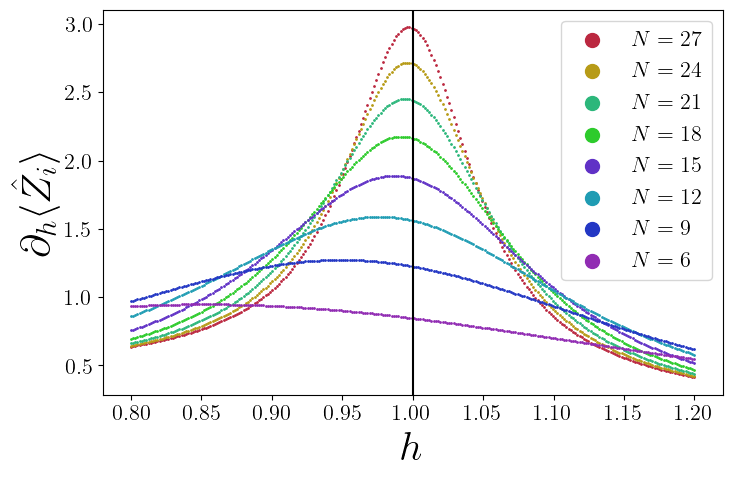

In [17]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))           

ax.set_prop_cycle(cycler('color', colors))               

ax.axvline(1.0,  color='black', linestyle='solid')

ax.scatter(h_values, dh__Z__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__Z__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Z}_{i} \rangle$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

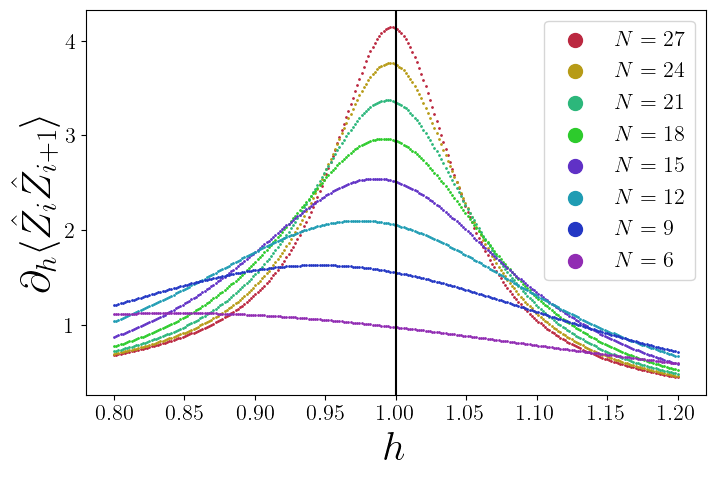

In [400]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__ZZ__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__ZZ__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Z}_{i} \hat{Z}_{i+1} \rangle$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

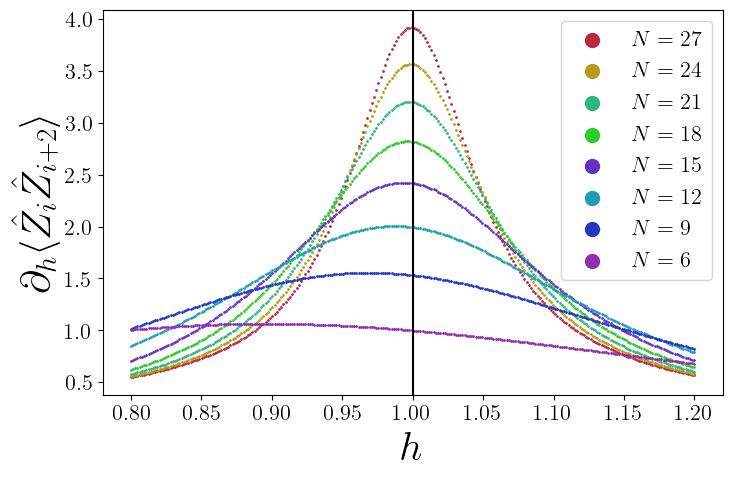

In [401]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__Z0Z__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__Z0Z__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Z}_{i}  \hat{Z}_{i+2} \rangle$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

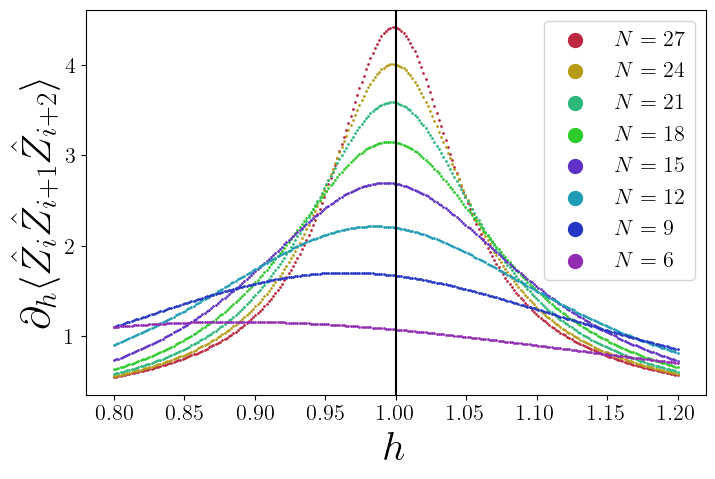

In [402]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__ZZZ__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__ZZZ__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Z}_{i}\hat{Z}_{i+1}\hat{Z}_{i+2} \rangle$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

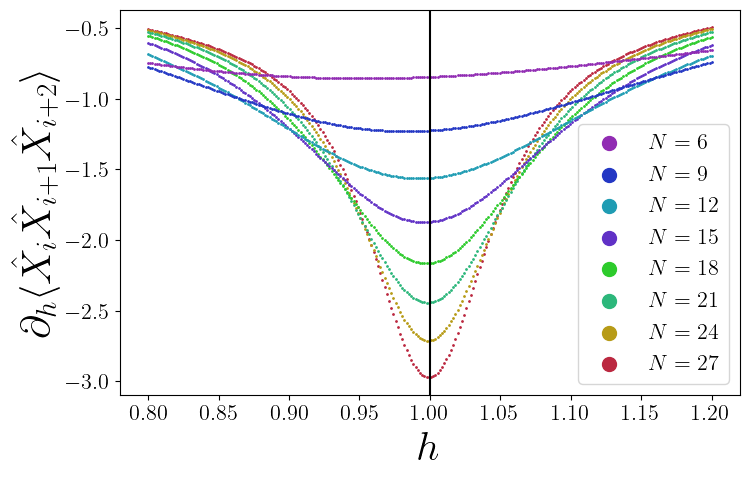

In [403]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__XXX__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__XXX__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{X}_{i}\hat{X}_{i+1}\hat{X}_{i+2} \rangle$', fontsize=30)
# ax.legend(loc='best', fontsize=16, markerscale=10)
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='lower right', fontsize=16, markerscale=10)  
plt.show()

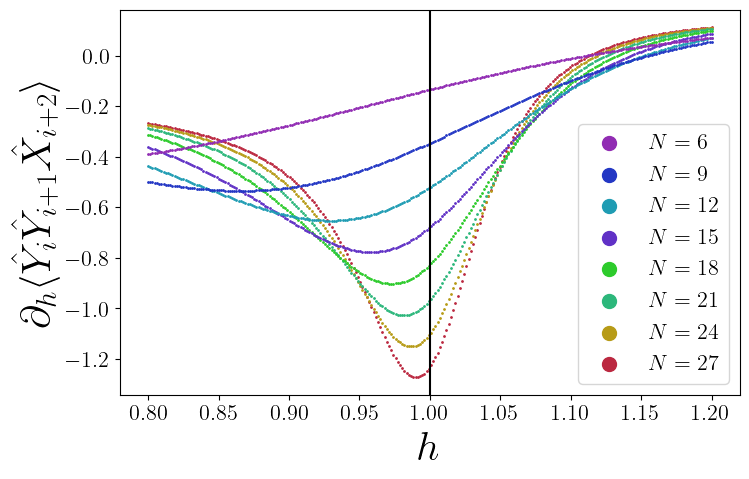

In [404]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__YYX__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__YYX__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Y}_{i}\hat{Y}_{i+1}\hat{X}_{i+2}\rangle$', fontsize=30)
# ax.legend(loc='best', fontsize=16, markerscale=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='best', fontsize=16, markerscale=10)  


plt.show()

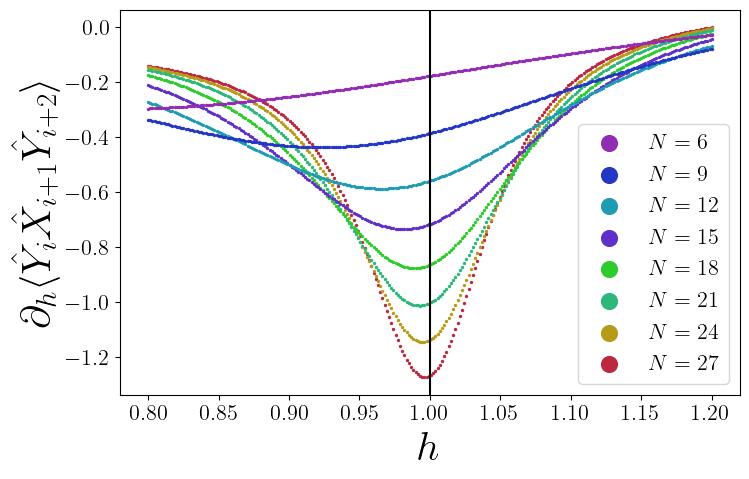

In [406]:
n_series = 12                                             
plotmarkerSize = 2
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))         

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, dh__YXY__27,  label=r'$N=27$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__24,  label=r'$N=24$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__21,  label=r'$N=21$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__18,  label=r'$N=18$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__15,  label=r'$N=15$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__12,  label=r'$N=12$', s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, dh__YXY__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'$\partial_h \langle \hat{Y}_{i}\hat{X}_{i+1}\hat{Y}_{i+2} \rangle$', fontsize=30)
# ax.legend(loc='best', fontsize=16, markerscale=10)
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='best', fontsize=16, markerscale=8)  
plt.show()

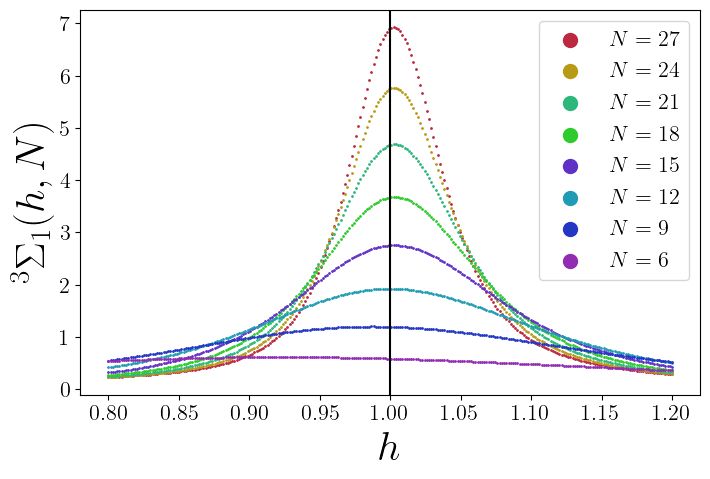

In [395]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))           

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, response__1__27,   label=r'$N=27$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__24,   label=r'$N=24$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__21,   label=r'$N=21$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__18,   label=r'$N=18$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__15,   label=r'$N=15$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__12,   label=r'$N=12$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, response__1__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'${}^3\Sigma_1(h, N)$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

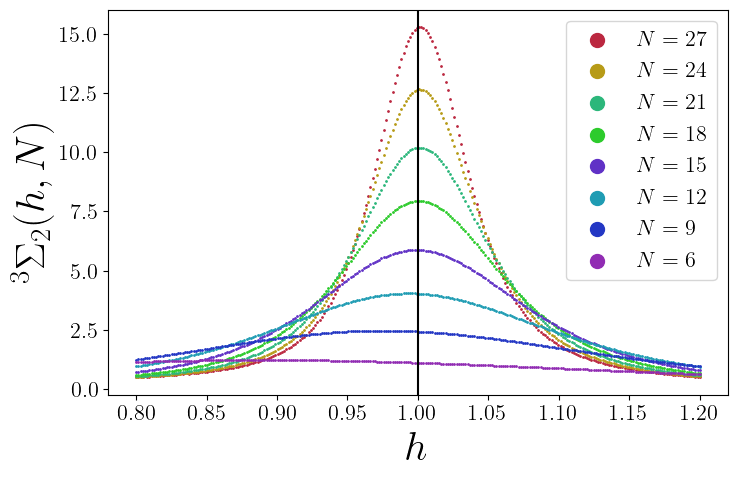

In [396]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))           

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, response__2__27,   label=r'$N=27$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__24,   label=r'$N=24$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__21,   label=r'$N=21$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__18,   label=r'$N=18$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__15,   label=r'$N=15$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__12,   label=r'$N=12$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, response__2__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'${}^3\Sigma_2(h, N)$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

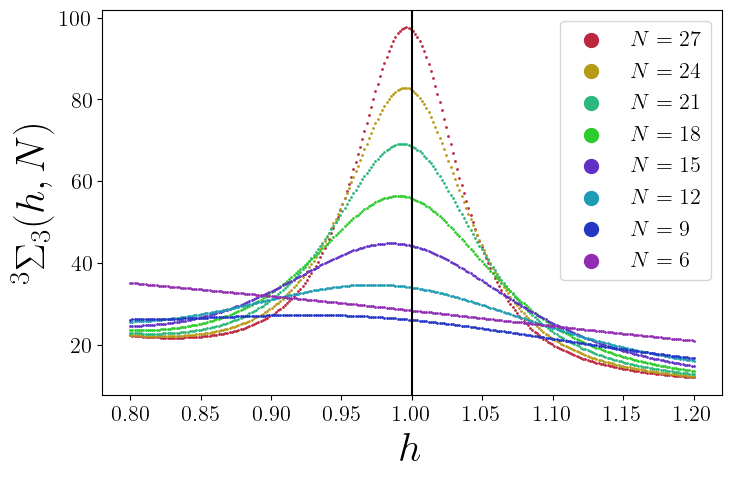

In [397]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 5))           

ax.set_prop_cycle(cycler('color', colors))               

ax.scatter(h_values, response__3__27,   label=r'$N=27$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__24,   label=r'$N=24$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__21,   label=r'$N=21$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__18,   label=r'$N=18$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__15,   label=r'$N=15$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__12,   label=r'$N=12$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__9,   label=r'$N=9$',  s=plotmarkerSize)
ax.scatter(h_values, response__3__6,   label=r'$N=6$',  s=plotmarkerSize)

ax.axvline(1.0,  color='black', linestyle='solid')

ax.set_xlabel(r'$h$', fontsize=30)
ax.set_ylabel(r'${}^3\Sigma_3(h, N)$', fontsize=30)
ax.legend(loc='best', fontsize=16, markerscale=10)
plt.show()

In [11]:
import scipy.optimize as optimize


def plot_polynomial_fit(x_vals: np.ndarray, y_vals: np.ndarray, fit_result: dict, title: str = 'Unimodal Polynomial Fit'):
    x_smooth = np.linspace(x_vals.min(), x_vals.max(), 200)

    poly_func = np.poly1d(fit_result['coefficients'])
    y_smooth = poly_func((x_smooth - np.mean(x_vals)) / np.std(x_vals))

    plt.figure(figsize=(8, 5))
    plt.scatter(x_vals, y_vals, label='Original Data', color='blue', marker='o')
    plt.plot(x_smooth, y_smooth, 'r-', label='Polynomial Fit', linewidth=2)

    maxima_x = fit_result['turning_point']
    extrema_y = fit_result['extrema_y']
    plt.scatter(
        maxima_x, 
        extrema_y, 
        color='green', 
        label='Maxima', 
        s=100, 
        zorder=5
    )
    plt.annotate(
        f'Turning Point\n(x = {maxima_x:.9f}, y = {extrema_y:.9f})', 
        (maxima_x, extrema_y),
        xytext=(0, -87),
        textcoords='offset points',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0')
    )
    plt.title(title)
    plt.xlabel('h_value')
    plt.ylabel('func_value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def fit_unimodal_polynomial(x_vals: np.ndarray, y_vals: np.ndarray, degree: int = 5, precision: float = 1e-15) -> dict:
    if len(x_vals) != len(y_vals):
        raise ValueError("x_vals and y_vals must have equal length")
    x_mean = np.mean(x_vals)
    x_std = np.std(x_vals)
    x_normalized = (x_vals - x_mean) / x_std
    coefficients = np.polyfit(x_normalized, y_vals, deg=degree)
    poly_func = np.poly1d(coefficients)
    first_derivative = np.polyder(poly_func)
    second_derivative = np.polyder(first_derivative)
    
    def first_deriv_func(x):
        return first_derivative(x)
    try:
        turning_point_normalized = optimize.brentq(
            first_deriv_func, 
            x_normalized.min(), 
            x_normalized.max(),
            xtol=precision,
            maxiter=1000, 
            disp=True,
        )
    except ValueError:
        raise ValueError("Could not find a unique turning point")

    turning_point = turning_point_normalized * x_std + x_mean
    extrema_y = poly_func(turning_point_normalized)

    y_pred = poly_func(x_normalized)
    r_squared = 1 - (np.sum((y_vals - y_pred)**2) / np.sum((y_vals - np.mean(y_vals))**2))

    is_maxima = second_derivative(turning_point_normalized) < -precision
    is_minima = second_derivative(turning_point_normalized) > precision
    
    return {
        'coefficients': coefficients,
        'turning_point': turning_point,
        'extrema_y': extrema_y,
        'r_squared': r_squared,
        'is_maxima': is_maxima,
        'is_minima': is_minima
    }



In [12]:
x = h_values
y = response__1__21
Window = 0.05 
mask = (x >= (1 - Window)) & (x <= (1 + Window))
x_vals = x[mask]
y_vals = y[mask]
fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
fit_result

{'coefficients': array([ 0.00258,  0.10509, -0.03486, -0.97389,  0.21619,  4.66292]),
 'turning_point': np.float64(1.0032056789336026),
 'extrema_y': np.float64(4.674889494089802),
 'r_squared': np.float64(0.9998805653718468),
 'is_maxima': np.True_,
 'is_minima': np.False_}

In [13]:
x = h_values
y = dh__XXX__21
Window = 0.05 
mask = (x >= (1 - Window)) & (x <= (1 + Window))
x_vals = x[mask]
y_vals = y[mask]
fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
fit_result

{'coefficients': array([ 0.00128, -0.02335, -0.01116,  0.2802 ,  0.03493, -2.44138]),
 'turning_point': np.float64(0.9981992321363289),
 'extrema_y': np.float64(-2.4424666495399596),
 'r_squared': np.float64(0.9999629863042291),
 'is_maxima': np.False_,
 'is_minima': np.True_}

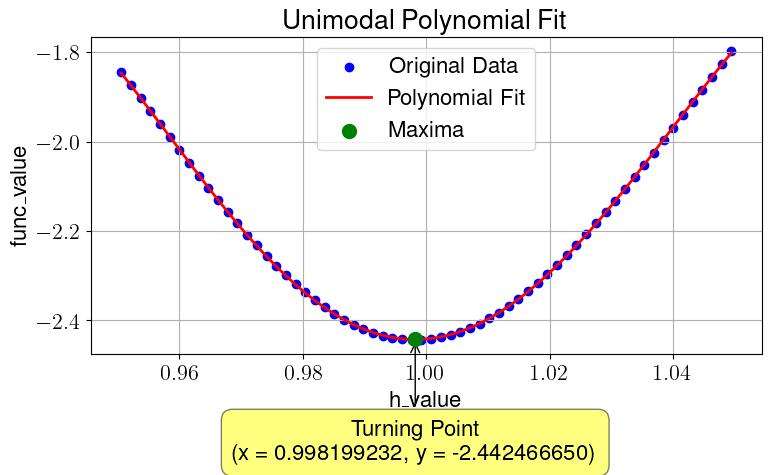

In [14]:
plot_polynomial_fit(x_vals, y_vals, fit_result)

In [15]:
size_list = [9, 12, 15, 18, 21, 24, 27]

## Turning points of : ${}^3\Sigma_m$

In [ ]:
def turning_point__(sys_size, rdm_size):
    #load data
    data_  = np.loadtxt(ff'{datafolder}{sys_size}__{rdm_size}.csv', delimiter=',')

    
    x = h_values
    y = data_
    Window = 0.05 
    mask = (x >= (1 - Window)) & (x <= (1 + Window))
    x_vals = x[mask]
    y_vals = y[mask]
    fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
    return fit_result['turning_point']


def peak__(sys_size, rdm_size):
    #load data
    data_  = np.loadtxt(ff'{datafolder}{sys_size}__{rdm_size}.csv', delimiter=',')
    x = h_values
    y = data_
    Window = 0.05 
    mask = (x >= (1 - Window)) & (x <= (1 + Window))
    x_vals = x[mask]
    y_vals = y[mask]
    fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
    return fit_result['extrema_y']

size_ = 9
rdm_size_ = 2
print('extrema_point = ', turning_point__(size_, rdm_size_))
print('extrema_point = ', peak__(size_, rdm_size_))

extrema_point =  0.9749515774906774
extrema_point =  2.463947572283758


In [22]:
extrema_point_list_for_rdm_size_1 = [turning_point__(size__, 1) for size__ in size_list]
extrema_point_list_for_rdm_size_1

[np.float64(0.9877477394334476),
 np.float64(0.9998373463484933),
 np.float64(1.0026553113015801),
 np.float64(1.0032332016795207),
 np.float64(1.0032056789336026),
 np.float64(1.0030270967745878),
 np.float64(1.0028308157172592)]

In [18]:
extrema_point_list_for_rdm_size_2 = [turning_point__(size__, 2) for size__ in size_list]
extrema_point_list_for_rdm_size_2

[np.float64(0.9749515774906774),
 np.float64(0.9932609754872982),
 np.float64(0.9987545888365279),
 np.float64(1.0006784304571401),
 np.float64(1.0014016634922132),
 np.float64(1.001674666271325),
 np.float64(1.001769421031251)]

In [19]:
extrema_point_list_for_rdm_size_3 = [turning_point__(size__, 3) for size__ in size_list[1:]]
extrema_point_list_for_rdm_size_3

[np.float64(0.97225448973208),
 np.float64(0.9848197785141819),
 np.float64(0.9901766102845031),
 np.float64(0.9929673892730303),
 np.float64(0.9946040148493529),
 np.float64(0.9956443757581269)]

In [21]:
extrema_value_list_for_rdm_size_1 = [peak__(size__, 1) for size__ in size_list]
extrema_value_list_for_rdm_size_1

[np.float64(1.2007168822401717),
 np.float64(1.9237567682876209),
 np.float64(2.7537534655252403),
 np.float64(3.6747896524323997),
 np.float64(4.674889494089802),
 np.float64(5.741414754489567),
 np.float64(6.859681620242317)]

In [29]:
extrema_value_list_for_rdm_size_2 = [peak__(size__, 2) for size__ in size_list]
extrema_value_list_for_rdm_size_2

[np.float64(2.463947572283758),
 np.float64(4.035225986030951),
 np.float64(5.868756475711934),
 np.float64(7.925660639852488),
 np.float64(10.17618757178624),
 np.float64(12.59015767275093),
 np.float64(15.131591208822254)]

In [23]:
extrema_value_list_for_rdm_size_3 = [peak__(size__, 3) for size__ in size_list[1:]]
extrema_value_list_for_rdm_size_3

[np.float64(34.73359846323899),
 np.float64(44.80432039629927),
 np.float64(56.37259502862993),
 np.float64(69.08220802063975),
 np.float64(82.7176995576036),
 np.float64(97.07843275593102)]

In [25]:
x = size_list
y = extrema_value_list_for_rdm_size_1

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for s=1 (b):", slope)
print("Estimated intercept for s=1 (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for s=1 (b): 1.5863589794510815
Estimated intercept for s=1 (log(a)): -3.291576617520516
RMSE of log-log fit: 0.00775138414366551


In [30]:
x = size_list
y = extrema_value_list_for_rdm_size_2

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for s=2 (b):", slope)
print("Estimated intercept for s=2 (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for s=2 (b): 1.6522144172547026
Estimated intercept for s=2 (log(a)): -2.7151159398589906
RMSE of log-log fit: 0.009412689483805662


In [31]:
x = size_list[1:]
y = extrema_value_list_for_rdm_size_3

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for s=3 (b):", slope)
print("Estimated intercept for s=3 (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for s=3 (b): 1.2731381079180213
Estimated intercept for s=3 (log(a)): 0.366466176247547
RMSE of log-log fit: 0.012155724228974055


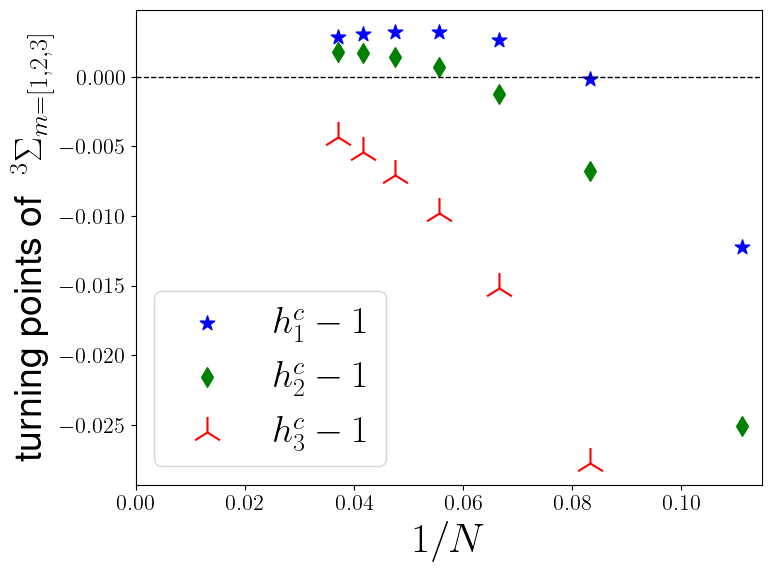

In [ ]:
## NUMERICALLY RELIABLE DATA

plt.figure(figsize=(8,6))

plt.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_rdm_size_1)-1.0, label=r'$h^c_1 -1$', s=120, marker="*", c='blue')
plt.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_rdm_size_2)-1.0, label=r'$h^c_2 -1$', s=100, marker="d", c="green")
plt.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_rdm_size_3)-1.0, label=r'$h^c_3 -1$', s=500, marker="2", c='red')


plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel(r'$1/N$', fontsize=30)
plt.ylabel(r'$ \text{turning points of } \ {}^3\Sigma_{m=[1,2,3]}$', fontsize=27)
plt.legend(loc='lower left', fontsize=27)
plt.xlim(left=0)
plt.tight_layout()



plt.show()

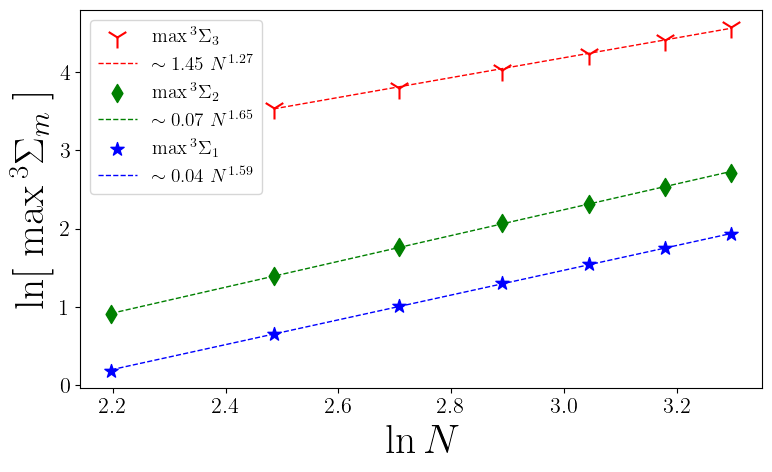

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list)

extrema_point_rdm__1_log = np.log(extrema_point_list_for_rdm_size_1)
extrema_point_rdm__2_log = np.log(extrema_point_list_for_rdm_size_2)
extrema_point_rdm__3_log = np.log(extrema_point_list_for_rdm_size_3)

# for s = 1
slope1, intercept1 = 1.5858737069508984, -3.2903663831173056
# for s = 2
slope2, intercept2 = 1.6521097190626644, -2.7148649891918955
# for s = 3
slope3, intercept3 = 1.2713214711358316, 0.37114181367132004

plt.figure(figsize=(8,5))

x_fit = np.linspace(size_values_log.min(), size_values_log.max(), 100)

x_fit__ = np.linspace(size_values_log[1:].min(), size_values_log[1:].max(), 100)


y1_fit = slope1 * x_fit + intercept1
y2_fit = slope2 * x_fit + intercept2
y3_fit = slope3 * x_fit__ + intercept3

plt.scatter(size_values_log[1:], extrema_point_rdm__3_log,
            label=r'$\max{}^3\Sigma_3$', s=250, marker="1", c='red')
plt.plot(x_fit__, y3_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 1.45 \  N^{ 1.27}$'
         ), c='red')

plt.scatter(size_values_log, extrema_point_rdm__2_log,
            label=r'$\max{}^3\Sigma_2$', s=85, marker="d", c='green')
plt.plot(x_fit, y2_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.07  \ N^{  1.65}$'
         ), c='green')

plt.scatter(size_values_log, extrema_point_rdm__1_log,
            label=r'$\max{}^3\Sigma_1$', s=100, marker="*", c='blue')

plt.plot(x_fit, y1_fit, linestyle='--', linewidth=1,
         label=(
             r'$ \sim 0.04 \ N^{ 1.59} \\$'
         ), c='blue')





plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max{}^3\Sigma_m\ ]$', fontsize=30)
plt.legend(loc='best', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
def turning_point_of_derivative_of_correlation_(sys_size, correlation_type):
    data_  = np.loadtxt(ff'{datafolder}dh__{correlation_type}__{sys_size}.csv', delimiter=',')
    x = h_values
    y = data_
    Window = 0.05 
    mask = (x >= (1 - Window)) & (x <= (1 + Window))
    x_vals = x[mask]
    y_vals = y[mask]
    fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
    return fit_result['turning_point']

def extrama_value_at_turning_point_of_derivative_of_correlation__(sys_size, correlation_type):
    data_  = np.loadtxt(ff'{datafolder}dh__{correlation_type}__{sys_size}.csv', delimiter=',')
    x = h_values
    y = data_
    Window = 0.05 
    mask = (x >= (1 - Window)) & (x <= (1 + Window))
    x_vals = x[mask]
    y_vals = y[mask]
    fit_result = fit_unimodal_polynomial(x_vals, y_vals, degree=5, precision=1e-27)
    return fit_result['extrema_y']

## Turning points of : $\partial_h \braket{\sigma^z_{i}}$

In [33]:
size_ = 27
correlation_type = 'Z'
print(f'N = {size_}, & dh__< Z >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< Z >
extrema_point =  0.9970982612946688
extrema_value =  2.96778803732727


In [35]:
extrema_point_list_for_dh__Z = [turning_point_of_derivative_of_correlation_(size__, 'Z') for size__ in size_list[1:]]
extrema_point_list_for_dh__Z

[np.float64(0.9763455505655736),
 np.float64(0.9868910581732249),
 np.float64(0.9918841574434021),
 np.float64(0.9945580695101522),
 np.float64(0.9961207543377579),
 np.float64(0.9970982612946688)]

In [36]:
extrema_value_list_for_dh__Z = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'Z') for size__ in size_list[1:]]
extrema_value_list_for_dh__Z

[np.float64(1.5897249517033654),
 np.float64(1.890142502295495),
 np.float64(2.1767353724365295),
 np.float64(2.451358720241353),
 np.float64(2.7150018245603307),
 np.float64(2.96778803732727)]

In [37]:
x = size_list[1:]
y = extrema_value_list_for_dh__Z

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__Z (b):", slope)
print("Estimated intercept for _dh__Z (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__Z (b): 0.770385781194752
Estimated intercept for _dh__Z (log(a)): -1.4498066870469324
RMSE of log-log fit: 0.0009121544404785125


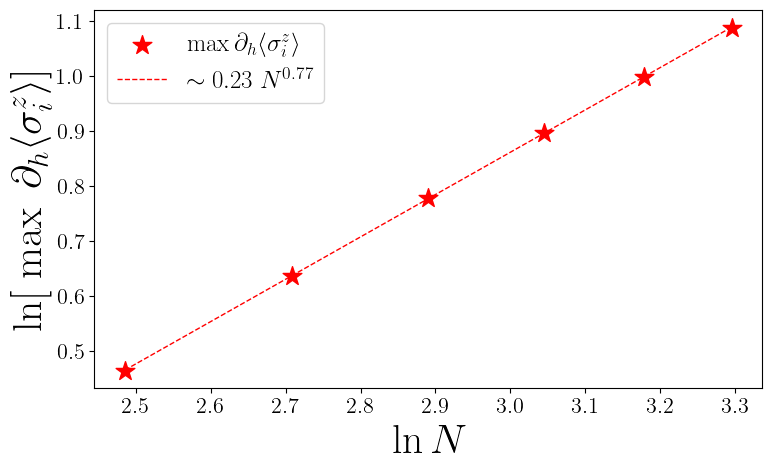

In [128]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list)

absolute_extrema_values_log = np.log(extrema_value_list_for_dh__Z)


slope, intercept = 0.770385781194752, -1.4498066870469324

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log[1:].min(), size_values_log[1:].max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log[1:], absolute_extrema_values_log,
            label=r'$\max \partial_h \langle \sigma^z_{i} \rangle$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.23 \  N^{0.77}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max \ \partial_h \langle \sigma^z_{i} \rangle ]$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [70]:
np.exp(-1.4498066870469324)

np.float64(0.23461563795210727)

## Turning points of : $\partial_h \braket{\sigma^z_{i}\sigma^z_{i+1}}$

In [39]:
size_ = 27
correlation_type = 'ZZ'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< ZZ >
extrema_point =  0.996619092974252
extrema_value =  4.127947517653688


In [40]:
extrema_point_list_for_dh__ZZ = [turning_point_of_derivative_of_correlation_(size__, 'ZZ') for size__ in size_list[1:]]
extrema_point_list_for_dh__ZZ


[np.float64(0.9739481078637494),
 np.float64(0.985332749419187),
 np.float64(0.9908029216484558),
 np.float64(0.9937673582620165),
 np.float64(0.9955166051174186),
 np.float64(0.996619092974252)]

In [41]:

extrema_value_list_for_dh__ZZ = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'ZZ') for size__ in size_list[1:]]
extrema_value_list_for_dh__ZZ

[np.float64(2.101198817137768),
 np.float64(2.5439392978606636),
 np.float64(2.96540987897327),
 np.float64(3.369030463308103),
 np.float64(3.756471171731959),
 np.float64(4.127947517653688)]

In [42]:
x = size_list[1:]
y = extrema_value_list_for_dh__ZZ

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__ZZ (b):", slope)
print("Estimated intercept for _dh__ZZ (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__ZZ (b): 0.8329075022055376
Estimated intercept for _dh__ZZ (log(a)): -1.3235833894210811
RMSE of log-log fit: 0.002772752414223566


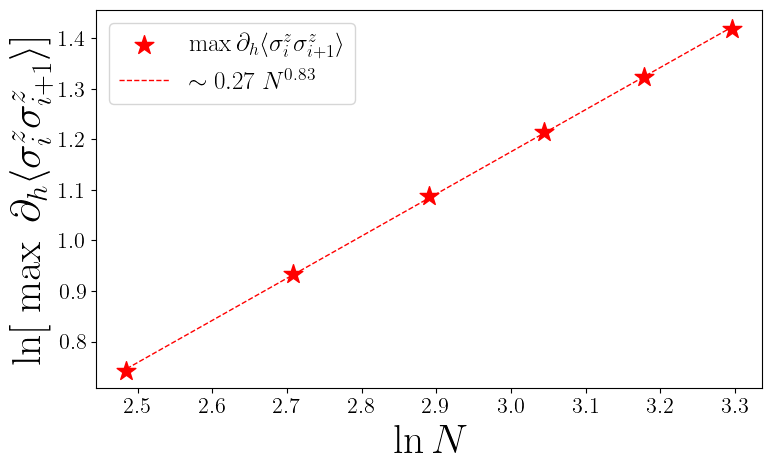

In [127]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list[1:])

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__ZZ))


slope, intercept = 0.8329075022055376, -1.3235833894210811

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$\max \partial_h \langle \sigma^z_{i}\sigma^z_{i+1} \rangle$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.27 \  N^{0.83}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max \ \partial_h \langle \sigma^z_{i}\sigma^z_{i+1} \rangle ]$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [85]:
np.exp(-1.3235833894210811)

np.float64(0.26617976520342984)

## Turning points of : $\partial_h \braket{\sigma^z_{i}\sigma^z_{i+2}}$

In [88]:
size_ = 27
correlation_type = 'Z0Z'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< Z0Z >
extrema_point =  0.9988796137889552
extrema_value =  3.9044413956087043


In [89]:
extrema_point_list_for_dh__Z0Z = [turning_point_of_derivative_of_correlation_(size__, 'Z0Z') for size__ in size_list]
extrema_point_list_for_dh__Z0Z

[np.float64(0.9692279418013854),
 np.float64(0.986966889400832),
 np.float64(0.993340212600155),
 np.float64(0.9961619155510528),
 np.float64(0.9975923794963757),
 np.float64(0.9983937332639624),
 np.float64(0.9988796137889552)]

In [90]:
extrema_value_list_for_dh__Z0Z = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'Z0Z') for size__ in size_list]
extrema_value_list_for_dh__Z0Z

[np.float64(1.555615991372824),
 np.float64(2.0044099432457547),
 np.float64(2.4230330129191797),
 np.float64(2.819000554335104),
 np.float64(3.1966912714183144),
 np.float64(3.558304664810749),
 np.float64(3.9044413956087043)]

In [91]:
x = size_list
y = extrema_value_list_for_dh__Z0Z

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__Z0Z (b):", slope)
print("Estimated intercept for _dh__Z0Z (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__Z0Z (b): 0.8365993414285652
Estimated intercept for _dh__Z0Z (log(a)): -1.3873804493926476
RMSE of log-log fit: 0.005919348601935743


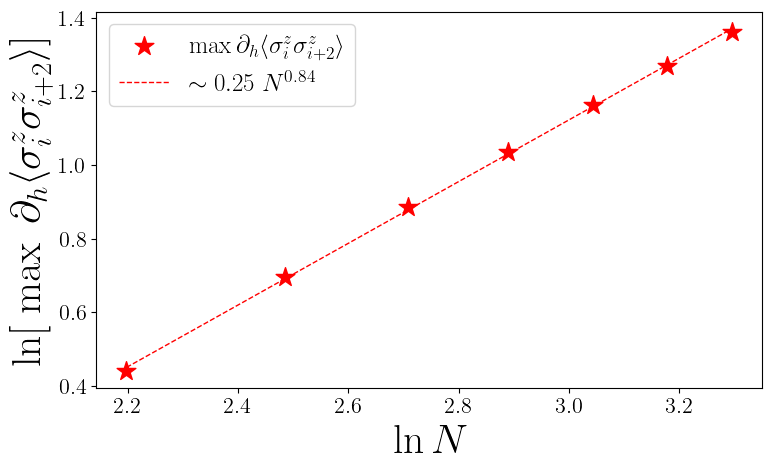

In [126]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list)

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__Z0Z))


slope, intercept = 0.8365993414285652, -1.3873804493926476

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$\max \partial_h \langle \sigma^z_{i}\sigma^z_{i+2} \rangle$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.25 \  N^{0.84}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max \ \partial_h \langle \sigma^z_{i}\sigma^z_{i+2} \rangle ]$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [92]:
np.exp(-1.3873804493926476)

np.float64(0.2497286253269116)

## Turning points of : $\partial_h \braket{\sigma^z_{i}\sigma^z_{i+1}\sigma^z_{i+2}}$

In [47]:
size_ = 27
correlation_type = 'ZZZ'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< ZZZ >
extrema_point =  0.9985240289397188
extrema_value =  4.4048783111725545


In [48]:
extrema_point_list_for_dh__ZZZ = [turning_point_of_derivative_of_correlation_(size__, 'ZZZ') for size__ in size_list]
extrema_point_list_for_dh__ZZZ


[np.float64(0.9657248782087153),
 np.float64(0.985023202842542),
 np.float64(0.992121252132987),
 np.float64(0.9953346942477058),
 np.float64(0.9969965422500255),
 np.float64(0.9979427706214679),
 np.float64(0.9985240289397188)]

In [49]:

extrema_value_list_for_dh__ZZZ = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'ZZZ') for size__ in size_list]
extrema_value_list_for_dh__ZZZ

[np.float64(1.700668837948356),
 np.float64(2.2133088908512435),
 np.float64(2.694635353855316),
 np.float64(3.1511146805252626),
 np.float64(3.5870969404264654),
 np.float64(4.004837670047561),
 np.float64(4.4048783111725545)]

In [97]:
x = size_list
y = extrema_value_list_for_dh__ZZZ

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__ZZZ (b):", slope)
print("Estimated intercept for _dh__ZZZ (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__ZZZ (b): 0.8652121293593913
Estimated intercept for _dh__ZZZ (log(a)): -1.3597453595406617
RMSE of log-log fit: 0.006876102141273354


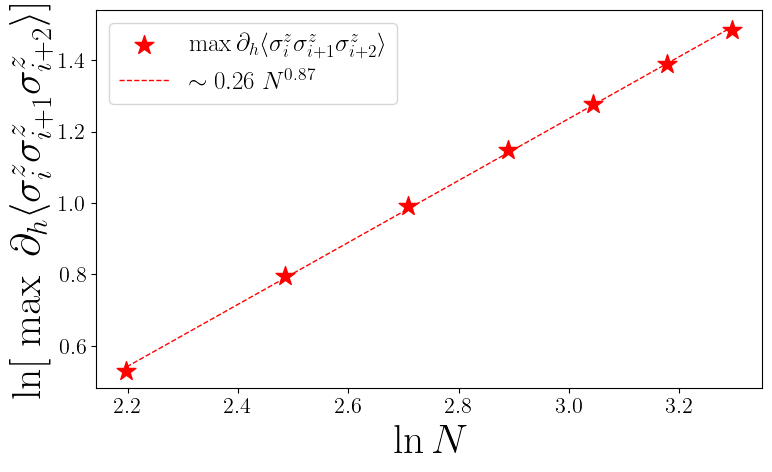

In [125]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list)

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__ZZZ))


slope, intercept = 0.8652121293593913, -1.3597453595406617

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$\max \partial_h \langle \sigma^z_{i}\sigma^z_{i+1}\sigma^z_{i+2} \rangle$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.26 \  N^{0.87}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max \ \partial_h \langle \sigma^z_{i}\sigma^z_{i+1}\sigma^z_{i+2}\rangle ]$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [101]:
np.exp(-1.3597453595406617)

np.float64(0.25672614149356854)

## Turning points of : $\partial_h \braket{\sigma^x_{i}\sigma^x_{i+1}\sigma^x_{i+1}}$

In [51]:
size_ = 27
correlation_type = 'XXX'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< XXX >
extrema_point =  0.9990642198109044
extrema_value =  -2.9620421515020676


In [103]:
extrema_point_list_for_dh__XXX = [turning_point_of_derivative_of_correlation_(size__, 'XXX') for size__ in size_list]
extrema_point_list_for_dh__XXX



[np.float64(0.9833583127186709),
 np.float64(0.9921599690981618),
 np.float64(0.9956430892576517),
 np.float64(0.9973036437671825),
 np.float64(0.9981992321363289),
 np.float64(0.9987282619415195),
 np.float64(0.9990642198109044)]

In [104]:

extrema_value_list_for_dh__XXX = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'XXX') for size__ in size_list]
extrema_value_list_for_dh__XXX

[np.float64(-1.2309986669805368),
 np.float64(-1.5647309650090657),
 np.float64(-1.873646563981427),
 np.float64(-2.1649654520198816),
 np.float64(-2.4424666495399596),
 np.float64(-2.707979428502845),
 np.float64(-2.9620421515020676)]

In [105]:
x = size_list
y = extrema_value_list_for_dh__XXX

logx = np.log(x)
logy = np.log(np.abs(extrema_value_list_for_dh__XXX))

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__XXX (b):", slope)
print("Estimated intercept for _dh__XXX (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__XXX (b): 0.7982635159132676
Estimated intercept for _dh__XXX (log(a)): -1.5391245249114758
RMSE of log-log fit: 0.0045764497080110125


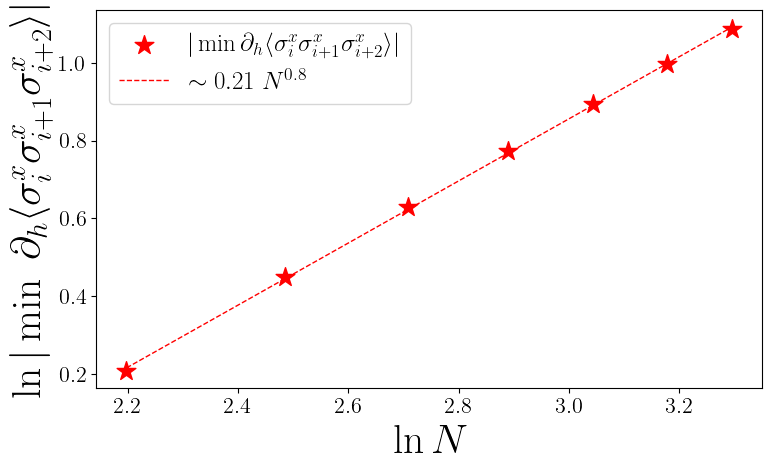

In [124]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list)

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__XXX))


slope, intercept =  0.7982635159132676, -1.5391245249114758

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$|\min \partial_h \langle \sigma^x_{i}\sigma^x_{i+1}\sigma^x_{i+2} \rangle|$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.21 \  N^{0.8}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln | \min \ \partial_h \langle \sigma^x_{i}\sigma^x_{i+1}\sigma^x_{i+2}\rangle |$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [106]:
np.exp(-1.5391245249114758)

np.float64(0.2145688689216167)

## Turning points of : $\partial_h \braket{\sigma^y_{i}\sigma^y_{i+1}\sigma^x_{i+1}} = \partial_h \braket{\sigma^x_{i}\sigma^y_{i+1}\sigma^y_{i+1}}$

In [59]:
size_ = 27
correlation_type = 'YYX'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< YYX >
extrema_point =  0.9893088315017935
extrema_value =  -1.271047341006235


In [60]:
extrema_point_list_for_dh__YYX = [turning_point_of_derivative_of_correlation_(size__, 'YYX') for size__ in size_list[2:]]
extrema_point_list_for_dh__YYX

[np.float64(0.9579382712301436),
 np.float64(0.9729182455228405),
 np.float64(0.9811862937294863),
 np.float64(0.9861460721655809),
 np.float64(0.9893088315017935)]

In [61]:
extrema_value_list_for_dh__YYX = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'YYX') for size__ in size_list[2:]]
extrema_value_list_for_dh__YYX

[np.float64(-0.7763593684387151),
 np.float64(-0.9020344190762569),
 np.float64(-1.0273598485304742),
 np.float64(-1.1507565114285998),
 np.float64(-1.271047341006235)]

In [108]:
x = size_list[2:]
y = extrema_value_list_for_dh__YYX

logx = np.log(x)
logy = np.log(np.abs(y))

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__YYX (b):", slope)
print("Estimated intercept for _dh__YYX (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__YYX (b): 0.8398220459203499
Estimated intercept for _dh__YYX (log(a)): -2.5288881361511586
RMSE of log-log fit: 0.0011370792701400848


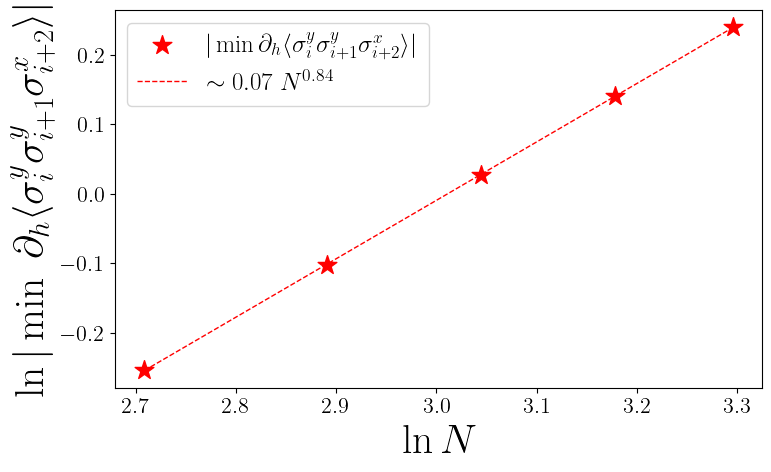

In [122]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list[2:])

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__YYX))

slope, intercept =  0.8398220459203499, -2.5288881361511586

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)

y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$| \min \partial_h \langle \sigma^y_{i}\sigma^y_{i+1}\sigma^x_{i+2} \rangle|$', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.07 \  N^{0.84}$'
         ), c='red')

plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln | \min \ \partial_h \langle \sigma^y_{i}\sigma^y_{i+1}\sigma^x_{i+2}\rangle |$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()

In [109]:
np.exp(-2.5288881361511586)

np.float64(0.07974763952792424)

## Turning points of : $\partial_h \braket{\sigma^y_{i}\sigma^x_{i+1}\sigma^y_{i+1}}$

In [63]:
size_ = 27
correlation_type = 'YXY'
print(f'N = {size_}, & dh__< {correlation_type} >')
print('extrema_point = ', turning_point_of_derivative_of_correlation_(size_, correlation_type))
print('extrema_value = ', extrama_value_at_turning_point_of_derivative_of_correlation__(size_, correlation_type))

N = 27, & dh__< YXY >
extrema_point =  0.9960577895899848
extrema_value =  -1.2704951679025647


In [64]:
extrema_point_list_for_dh__YXY = [turning_point_of_derivative_of_correlation_(size__, 'YXY') for size__ in size_list[1:]]
extrema_point_list_for_dh__YXY

[np.float64(0.96563240197205),
 np.float64(0.9813873794439182),
 np.float64(0.9886539041026969),
 np.float64(0.9924811179583909),
 np.float64(0.9946903894339169),
 np.float64(0.9960577895899848)]

In [113]:
extrema_value_list_for_dh__YXY = [extrama_value_at_turning_point_of_derivative_of_correlation__(size__, 'YXY') for size__ in size_list[1:]]
extrema_value_list_for_dh__YXY

[np.float64(-0.5884396073141615),
 np.float64(-0.7354125947284565),
 np.float64(-0.8769954315947461),
 np.float64(-1.0133075174870059),
 np.float64(-1.1445106394698799),
 np.float64(-1.2704951679025647)]

In [114]:
x = size_list[1:]
y = extrema_value_list_for_dh__YXY

logx = np.log(x)
logy = np.log(np.abs(y))

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for _dh__XXX (b):", slope)
print("Estimated intercept for _dh__XXX (log(a)):", intercept)
print("RMSE of log-log fit:", rmse)

Estimated slope for _dh__XXX (b): 0.9492237477186279
Estimated intercept for _dh__XXX (log(a)): -2.881540949141504
RMSE of log-log fit: 0.0056874770001153555


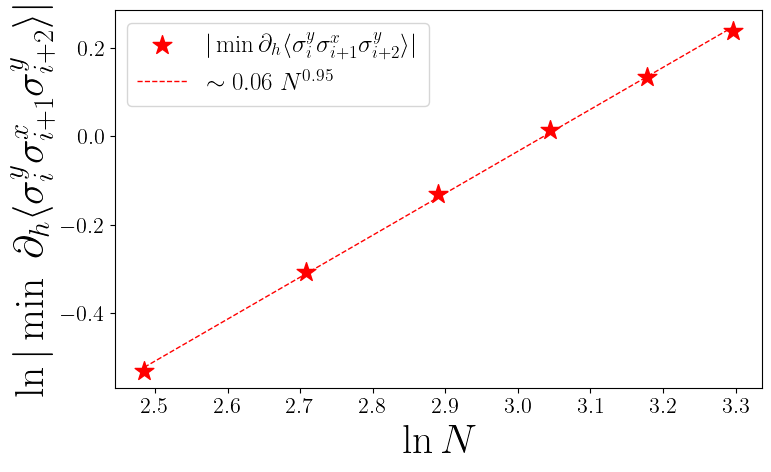

In [121]:
import numpy as np
import matplotlib.pyplot as plt

size_values_log = np.log(size_list[1:])

absolute_extrema_values_log = np.log(np.abs(extrema_value_list_for_dh__YXY))


slope, intercept =  0.9492237477186279, -2.881540949141504

plt.figure(figsize=(8,5))

x_fit__ = np.linspace(size_values_log.min(), size_values_log.max(), 100)


y_fit = slope * x_fit__ + intercept

plt.scatter(size_values_log, absolute_extrema_values_log,
            label=r'$|\min \partial_h \langle \sigma^y_{i}\sigma^x_{i+1}\sigma^y_{i+2} \rangle | $', s=200, marker="*", c='red')
plt.plot(x_fit__, y_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.06 \  N^{0.95}$'
         ), c='red')


plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln  |\min \ \partial_h \langle \sigma^y_{i}\sigma^x_{i+1}\sigma^y_{i+2}\rangle |$', fontsize=30)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.show()


In [116]:
np.exp(-2.881540949141504)

np.float64(0.05604832863199408)

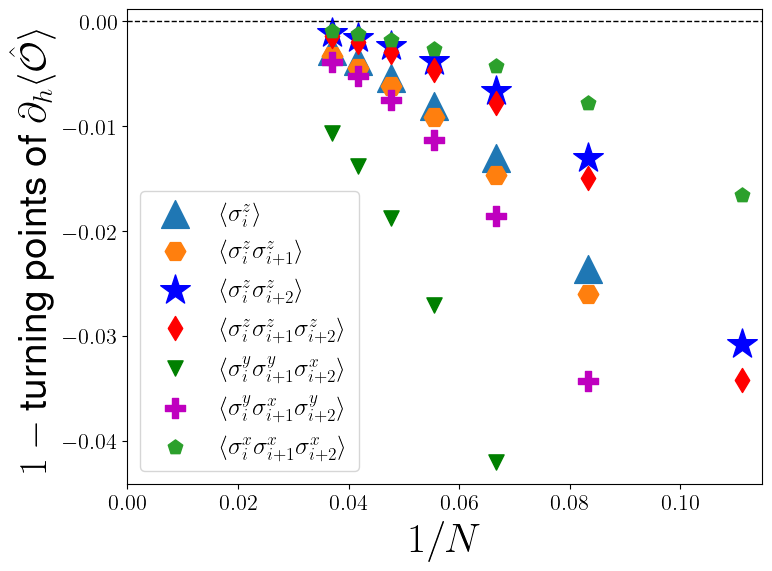

In [ ]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 6))           

# ax.set_prop_cycle(cycler('color', colors))   

ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__Z)-1.0, label = r'$ \langle \hat{Z}_{i} \rangle$', marker="^",s=400)
ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__ZZ)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1} \rangle$',s=220,  marker="H")
ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__Z0Z)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+2} \rangle$',s=500,  marker="*", c='blue')

ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__ZZZ)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1}\hat{Z}_{i+2} \rangle$', s=150, marker="d", c='red')
ax.scatter(1.0/np.array(size_list[2:]), np.array(extrema_point_list_for_dh__YYX)-1.0,label = r'$ \langle \hat{Y}_{i}\hat{Y}_{i+1}\hat{X}_{i+2} \rangle$', s=120, marker="v", c='green')

ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__YXY)-1.0,  label = r'$ \langle \hat{Y}_{i}\hat{X}_{i+1}\hat{Y}_{i+2} \rangle$', s=200, marker="P", c='m')

ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__XXX)-1.0, label = r'$ \langle \hat{X}_{i}\hat{X}_{i+1}\hat{X}_{i+2} \rangle$', s=120, marker="p")
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

ax.set_xlabel(r'$1/N$', fontsize=30)
ax.set_ylabel(r'$1-\text{turning points of} \ \partial_h \langle \hat{\mathcal{O}} \rangle$', fontsize=28)
ax.legend(loc='best', fontsize=18)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

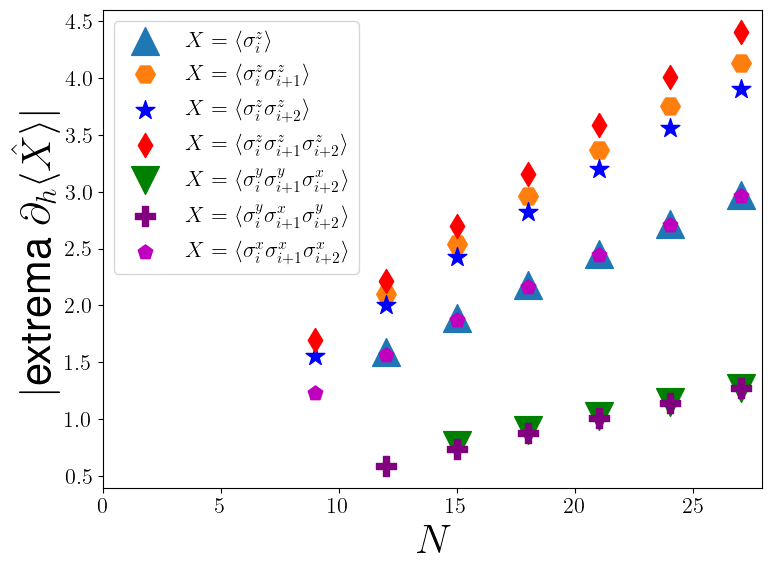

In [372]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 6))           

# ax.set_prop_cycle(cycler('color', colors))   

ax.scatter(np.array(size_list[1:]), np.array(extrema_value_list_for_dh__Z), label = r'$X =  \langle \sigma^z_{i} \rangle$', marker="^",s=400)
ax.scatter(np.array(size_list[1:]), np.array(extrema_value_list_for_dh__ZZ), label = r'$X =  \langle \sigma^z_{i}\sigma^z_{i+1} \rangle$',s=200,  marker="H")
ax.scatter(np.array(size_list), np.array(extrema_value_list_for_dh__Z0Z), label = r'$X =  \langle \sigma^z_{i}\sigma^z_{i+2} \rangle$',s=200,  marker="*", c='blue')

ax.scatter(np.array(size_list), np.array(extrema_value_list_for_dh__ZZZ), label = r'$X =  \langle \sigma^z_{i}\sigma^z_{i+1}\sigma^z_{i+2} \rangle$', s=150, marker="d", c='red')
ax.scatter(np.array(size_list[2:]), np.abs(np.array(extrema_value_list_for_dh__YYX)),label = r'$X =  \langle \sigma^y_{i}\sigma^y_{i+1}\sigma^x_{i+2} \rangle$', s=400, marker="v", c='green')

ax.scatter(np.array(size_list[1:]), np.abs(np.array(extrema_value_list_for_dh__YXY)),  label = r'$X =  \langle \sigma^y_{i}\sigma^x_{i+1}\sigma^y_{i+2} \rangle$', s=200, marker="P", c='purple')

ax.scatter(np.array(size_list), np.abs(np.array(extrema_value_list_for_dh__XXX)), label = r'$X =  \langle \sigma^x_{i}\sigma^x_{i+1}\sigma^x_{i+2} \rangle$', s=120, marker="p", c='m')

ax.set_xlabel(r'$N$', fontsize=30)
ax.set_ylabel(r'$|\text{extrema} \ \partial_h\langle \hat{X} \rangle|$', fontsize=30)
ax.legend(loc='best', fontsize=16)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

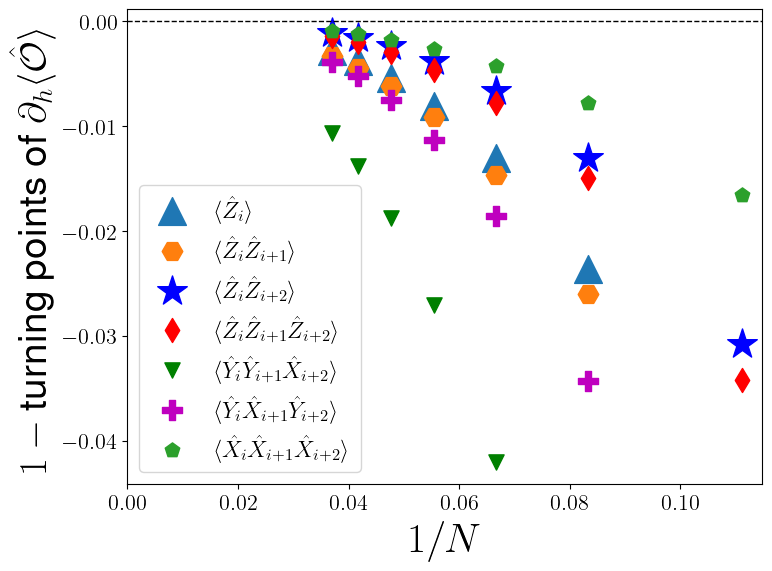

In [394]:
n_series = 12                                             
plotmarkerSize = 1
colors = distinct_subdued_colors(n_series, seed=5, sat_range=(0.7, 0.9), val_range=(0.7, 0.8), hue_jitter=0.05)                             

fig, ax = plt.subplots(figsize=(8, 6))           

# ax.set_prop_cycle(cycler('color', colors))   

ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__Z)-1.0, label = r'$ \langle \hat{Z}_{i} \rangle$', marker="^",s=400)
ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__ZZ)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1} \rangle$',s=220,  marker="H")
ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__Z0Z)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+2} \rangle$',s=500,  marker="*", c='blue')

ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__ZZZ)-1.0, label = r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1}\hat{Z}_{i+2} \rangle$', s=150, marker="d", c='red')
ax.scatter(1.0/np.array(size_list[2:]), np.array(extrema_point_list_for_dh__YYX)-1.0,label = r'$ \langle \hat{Y}_{i}\hat{Y}_{i+1}\hat{X}_{i+2} \rangle$', s=120, marker="v", c='green')

ax.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_dh__YXY)-1.0,  label = r'$ \langle \hat{Y}_{i}\hat{X}_{i+1}\hat{Y}_{i+2} \rangle$', s=200, marker="P", c='m')

ax.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_dh__XXX)-1.0, label = r'$ \langle \hat{X}_{i}\hat{X}_{i+1}\hat{X}_{i+2} \rangle$', s=120, marker="p")
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

ax.set_xlabel(r'$1/N$', fontsize=30)
ax.set_ylabel(r'$1-\text{turning points of} \ \partial_h \langle \hat{\mathcal{O}} \rangle$', fontsize=28)
ax.legend(loc='best', fontsize=17)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

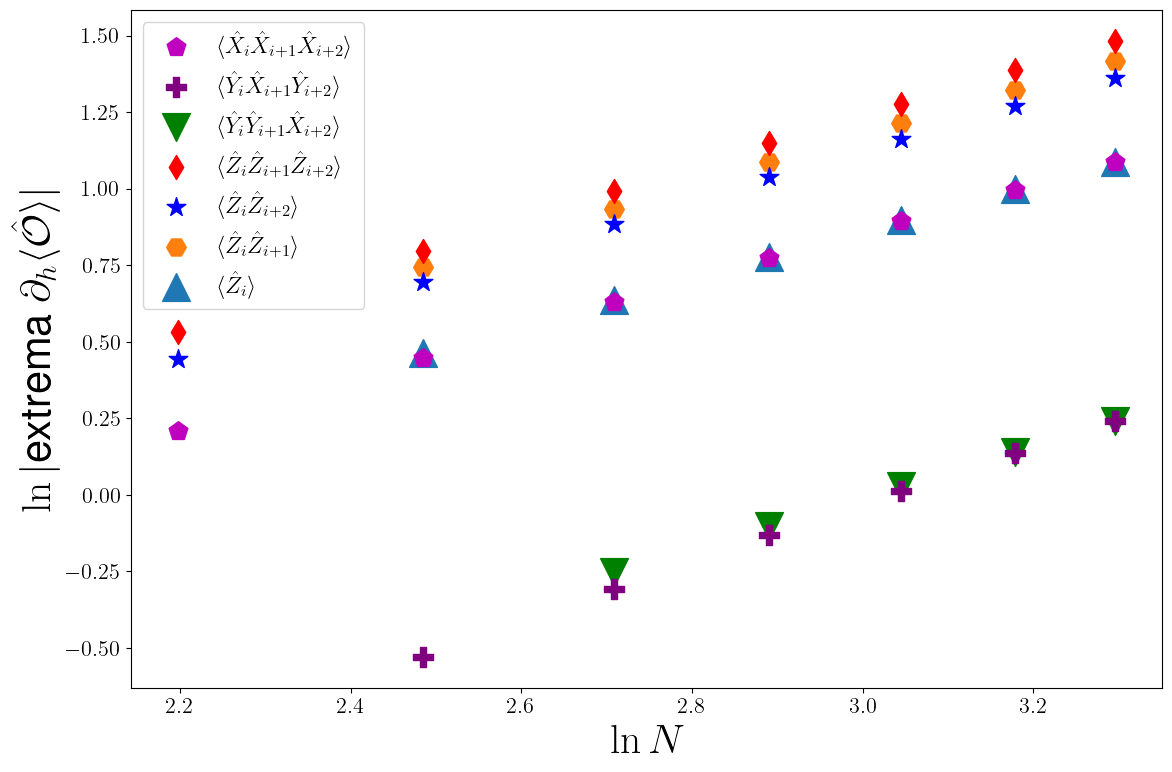

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_series = 12                                             
plotmarkerSize = 1

colors = distinct_subdued_colors(
    n_series,
    seed=5,
    sat_range=(0.7, 0.9),
    val_range=(0.7, 0.8),
    hue_jitter=0.05
)

fig, ax = plt.subplots(figsize=(12, 8))

# Apply natural log to both x and y (ensuring values are > 0)
def safe_ln(array):
    return np.log(np.array(array))

ax.scatter(
    safe_ln(size_list[1:]),
    safe_ln(np.abs(extrema_value_list_for_dh__Z)),
    label=r'$ \langle \hat{Z}_{i} \rangle$',
    marker="^",
    s=400
)
ax.scatter(
    safe_ln(size_list[1:]),
    safe_ln(np.abs(extrema_value_list_for_dh__ZZ)),
    label=r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1} \rangle$',
    s=200,
    marker="H"
)
ax.scatter(
    safe_ln(size_list),
    safe_ln(np.abs(extrema_value_list_for_dh__Z0Z)),
    label=r'$ \langle \hat{Z}_{i}\hat{Z}_{i+2} \rangle$',
    s=200,
    marker="*",
    c='blue'
)
ax.scatter(
    safe_ln(size_list),
    safe_ln(np.abs(extrema_value_list_for_dh__ZZZ)),
    label=r'$ \langle \hat{Z}_{i}\hat{Z}_{i+1}\hat{Z}_{i+2} \rangle$',
    s=150,
    marker="d",
    c='red'
)
ax.scatter(
    safe_ln(size_list[2:]),
    safe_ln(np.abs(extrema_value_list_for_dh__YYX)),
    label=r'$ \langle \hat{Y}_{i}\hat{Y}_{i+1}\hat{X}_{i+2} \rangle$',
    s=400,
    marker="v",
    c='green'
)
ax.scatter(
    safe_ln(size_list[1:]),
    safe_ln(np.abs(extrema_value_list_for_dh__YXY)),
    label=r'$ \langle \hat{Y}_{i}\hat{X}_{i+1}\hat{Y}_{i+2} \rangle$',
    s=200,
    marker="P",
    c='purple'
)
ax.scatter(
    safe_ln(size_list),
    safe_ln(np.abs(extrema_value_list_for_dh__XXX)),
    label=r'$ \langle \hat{X}_{i}\hat{X}_{i+1}\hat{X}_{i+2} \rangle$',
    s=200,
    marker="p",
    c='m'
)

ax.set_xlabel(r'$\ln N$', fontsize=30)
ax.set_ylabel(r'$\ln|\text{extrema} \ \partial_h \langle  \hat{\mathcal{O}} \rangle|$', fontsize=30)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='best', fontsize=17)


# ax.legend(loc='best', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
x = size_list[1:]

correlation_type = 'Z'

y = extrema_point_list_for_dh__Z

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)

logy_pred = slope * logx + intercept
residuals = logy - logy_pred
rmse = np.sqrt(np.mean(residuals ** 2))

print("Estimated slope for dh__Z (exponent):", slope)
print("Estimated intercept for dh__Z (log(coefficient)):", intercept)
print("RMSE of log-log fit:", rmse)



def linear_fit_of_log_log_of_absolute_turning_points_of_correlation_data__(correlation_type, size_list_used):
    x = size_list_used

    correlation_type == 'Z'

    if correlation_type == 'Z':
        y = extrema_point_list_for_dh__Z
    elif correlation_type == 'ZZ':
        y = extrema_point_list_for_dh__ZZ
    elif correlation_type == 'Z0Z':
        y = extrema_point_list_for_dh__Z0Z
    elif correlation_type == 'ZZZ':
        y = extrema_point_list_for_dh__ZZZ
    elif correlation_type == 'XXX':
        y = extrema_point_list_for_dh__XXX
    elif correlation_type == 'YYX':
        y = extrema_point_list_for_dh__YYX
    elif correlation_type == 'YXY':
        y = extrema_point_list_for_dh__YXY
    else:
        raise ValueError(f"Unknown correlation_type: {correlation_type}")

    logx = np.log(x)
    logy = np.log(y)

    slope, intercept = np.polyfit(logx, logy, 1)

    logy_pred = slope * logx + intercept
    residuals = logy - logy_pred
    rmse = np.sqrt(np.mean(residuals ** 2))


In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_rdm_size_1)-1.0, label=r'$h^c_1 -1$', s=120, marker="*", c='blue')
plt.scatter(1.0/np.array(size_list), np.array(extrema_point_list_for_rdm_size_2)-1.0, label=r'$h^c_2 -1$', s=100, marker="d", c="green")
plt.scatter(1.0/np.array(size_list[1:]), np.array(extrema_point_list_for_rdm_size_3)-1.0, label=r'$h^c_3 -1$', s=500, marker="2", c='red')


plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel(r'$1/N$', fontsize=30)
plt.ylabel(r'$ \text{turning points of } \ {}^3\Sigma_{m=[1,2,3]}$', fontsize=27)
plt.legend(loc='lower left', fontsize=27)
plt.xlim(left=0)
plt.tight_layout()



plt.show()

size_values_log = np.log(size_list)

extrema_point_rdm__1_log = np.log(extrema_point_list_for_rdm_size_1)
extrema_point_rdm__2_log = np.log(extrema_point_list_for_rdm_size_2)
extrema_point_rdm__3_log = np.log(extrema_point_list_for_rdm_size_3)

# for s = 1
slope1, intercept1 = 1.5858737069508984, -3.2903663831173056
# for s = 2
slope2, intercept2 = 1.6521097190626644, -2.7148649891918955
# for s = 3
slope3, intercept3 = 1.2713214711358316, 0.37114181367132004

plt.figure(figsize=(8,5))

x_fit = np.linspace(size_values_log.min(), size_values_log.max(), 100)

x_fit__ = np.linspace(size_values_log[1:].min(), size_values_log[1:].max(), 100)


y1_fit = slope1 * x_fit + intercept1
y2_fit = slope2 * x_fit + intercept2
y3_fit = slope3 * x_fit__ + intercept3

plt.scatter(size_values_log[1:], extrema_point_rdm__3_log,
            label=r'$\max{}^3\Sigma_3$', s=250, marker="1", c='red')
plt.plot(x_fit__, y3_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 1.45 \  N^{ 1.27}$'
         ), c='red')

plt.scatter(size_values_log, extrema_point_rdm__2_log,
            label=r'$\max{}^3\Sigma_2$', s=85, marker="d", c='green')
plt.plot(x_fit, y2_fit, linestyle='--', linewidth=1,
         label=(
             r'$\sim 0.07  \ N^{  1.65}$'
         ), c='green')

plt.scatter(size_values_log, extrema_point_rdm__1_log,
            label=r'$\max{}^3\Sigma_1$', s=100, marker="*", c='blue')

plt.plot(x_fit, y1_fit, linestyle='--', linewidth=1,
         label=(
             r'$ \sim 0.04 \ N^{ 1.59} \\$'
         ), c='blue')





plt.xlabel(r'$\ln N$', fontsize=30)
plt.ylabel(r'$\ln [ \ \max{}^3\Sigma_m\ ]$', fontsize=30)
plt.legend(loc='best', fontsize=14)
plt.tight_layout()
plt.show()